In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_bank_churn.csv")

In [18]:
# add no. above bars
def add_bar_labels(ax, suffix="%"):
    for container in ax.containers:
        labels = [
            f"{bar.get_height():.2f}{suffix}"
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3
        )

In [2]:
# overall churn rate
churn_rate = df["Exited"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.38%


## Churn Rate by Geography

This chart compares churn rates across customer countries.

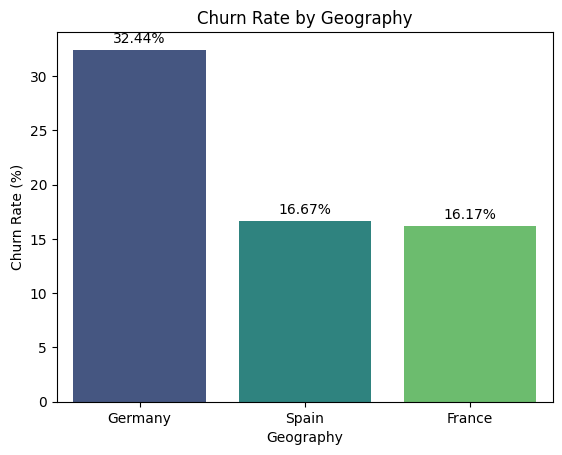

In [19]:
# churn by geography
geo_churn = (
    df.groupby("Geography")["Exited"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

geo_churn["Exited"] *= 100

ax = sns.barplot(
    data=geo_churn,
    x="Geography",
    y="Exited",
    hue="Geography",
    palette="viridis",
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Geography")
plt.show()

### Insight

Germany has the highest churn rate compared to France and Spain. This suggests that geography may be an important churn driver and should be considered in both the dashboard and prediction model.

## Churn Rate by Gender

This chart compares churn rates between male and female customers.

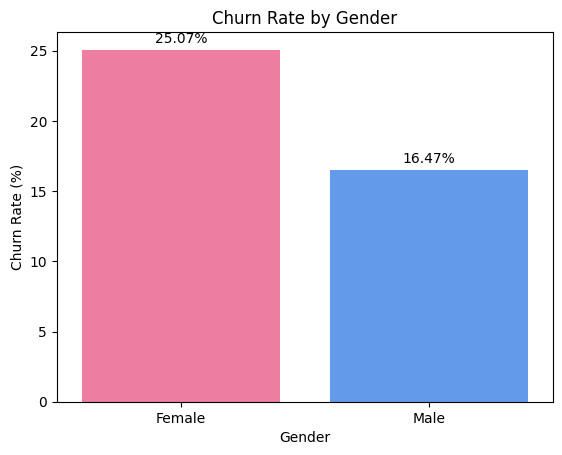

In [20]:
# churn by gender
gender_churn = (
    df.groupby("Gender")["Exited"]
    .mean()
    .reset_index()
)

gender_churn["Exited"] *= 100

ax = sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Exited",
    hue="Gender",
    palette=["#FF6B9A", "#4D96FF"],
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Gender")
plt.show()

### Insight

Female customers show a higher churn rate than male customers. This does not automatically mean gender causes churn, but it may interact with other factors such as product usage, complaints, or customer engagement.

## Churn Rate by Age Group

This chart shows how churn rate changes across different customer age groups.

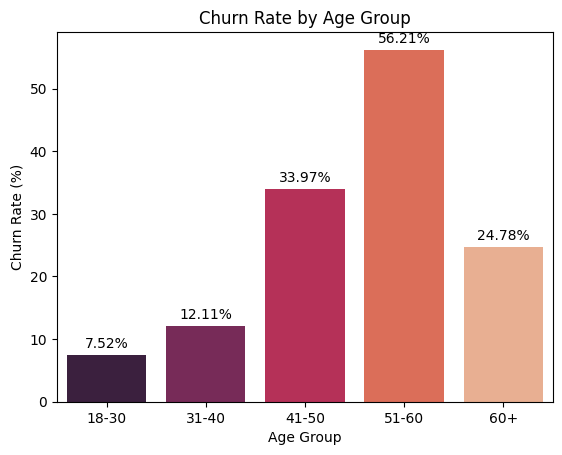

In [21]:
# churn by age group
age_churn = (
    df.groupby("AgeGroup")["Exited"]
    .mean()
    .reset_index()
)

age_churn["Exited"] *= 100

ax = sns.barplot(
    data=age_churn,
    x="AgeGroup",
    y="Exited",
    hue="AgeGroup",
    palette="rocket",
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Older customer groups appear to have higher churn rates than younger customers. Age may be an important factor in churn behaviour and should be included in future modelling and segmentation.

## Churn Rate by Activity Status

This chart compares churn rates between active and inactive customers.

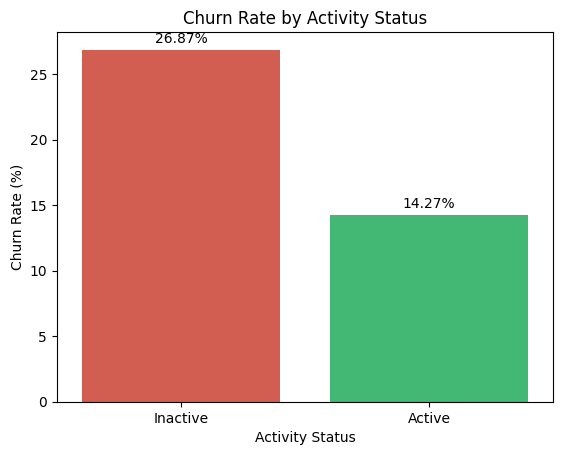

In [22]:
# churn by active status
active_churn = (
    df.groupby("IsActiveMember")["Exited"]
    .mean()
    .reset_index()
)

active_churn["Exited"] *= 100
active_churn["Status"] = active_churn["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

ax = sns.barplot(
    data=active_churn,
    x="Status",
    y="Exited",
    hue="Status",
    palette=["#E74C3C", "#2ECC71"],
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Inactive customers have a higher churn rate than active customers. This suggests that engagement is strongly related to retention, and inactive customers should be prioritised in retention campaigns.

## Churn Rate by Complaint Status

This chart compares churn rates between customers who complained and customers who did not.

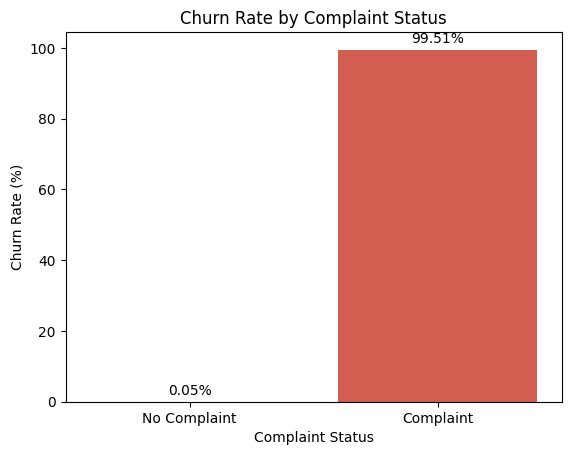

In [23]:
# churn by complaint
complain_churn = (
    df.groupby("Complain")["Exited"]
    .mean()
    .reset_index()
)

complain_churn["Exited"] *= 100
complain_churn["Complaint Status"] = complain_churn["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

ax = sns.barplot(
    data=complain_churn,
    x="Complaint Status",
    y="Exited",
    hue="Complaint Status",
    palette=["#3498DB", "#E74C3C"],
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customers who made a complaint show a much higher churn rate. This indicates that complaint handling may be a major retention opportunity for the bank.

## Churn Rate by Satisfaction Score

This chart shows churn rates across customer satisfaction scores.

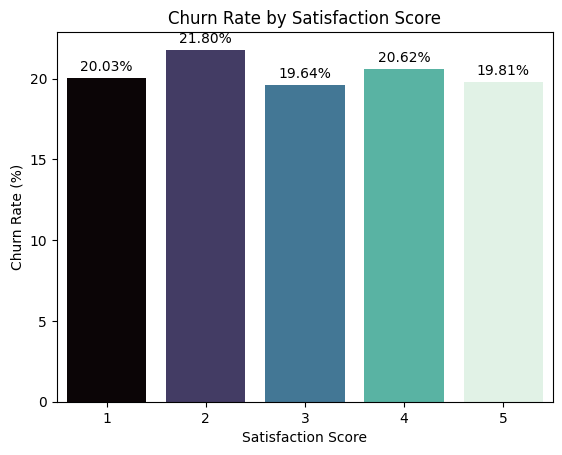

In [24]:
# churn by satisfaction score
sat_churn = (
    df.groupby("SatisfactionScore")["Exited"]
    .mean()
    .reset_index()
)

sat_churn["Exited"] *= 100

ax = sns.barplot(
    data=sat_churn,
    x="SatisfactionScore",
    y="Exited",
    hue="SatisfactionScore",
    palette="mako",
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customer satisfaction score appears to have little relationship with churn in this dataset. Churn rates remain relatively consistent across all satisfaction levels (around 20%), suggesting that satisfaction score alone is not a strong predictor of customer attrition.

## Churn Rate by Number of Products

This chart shows how churn rate varies based on the number of bank products owned by each customer.

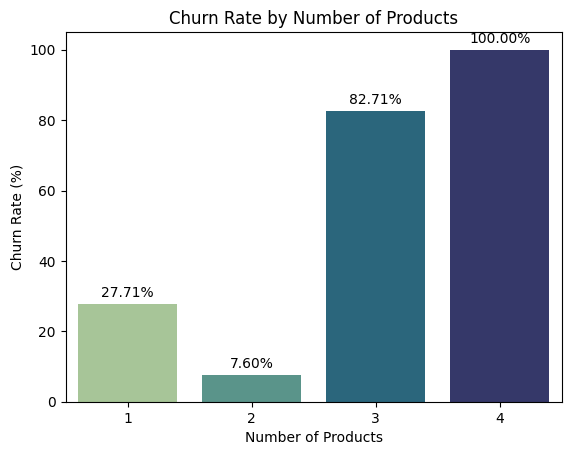

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [28]:
# churn by number of products
product_churn = (
    df.groupby("NumOfProducts")["Exited"]
    .mean()
    .reset_index()
)

product_churn["Exited"] *= 100

ax = sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="Exited",
    hue="NumOfProducts",
    palette="crest",
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show()

df["NumOfProducts"].value_counts()

### Insight

The number of products owned appears to be a strong churn indicator. Customers with two products have the lowest churn rate (7.6%), while customers with three (82.7%) and four products (100%) show much higher churn. However, the four-product group contains only 60 customers, so the 100% churn rate should be interpreted carefully because it is based on a small segment.

### Sample Size Check

The product groups are not evenly distributed. Most customers own one or two products, while only 266 customers own three products and 60 customers own four products. This means the high churn rates for three and four products are useful signals, but should be validated carefully before making business decisions.

## Churn Rate by Balance Group

This chart shows churn rates across different customer balance groups.

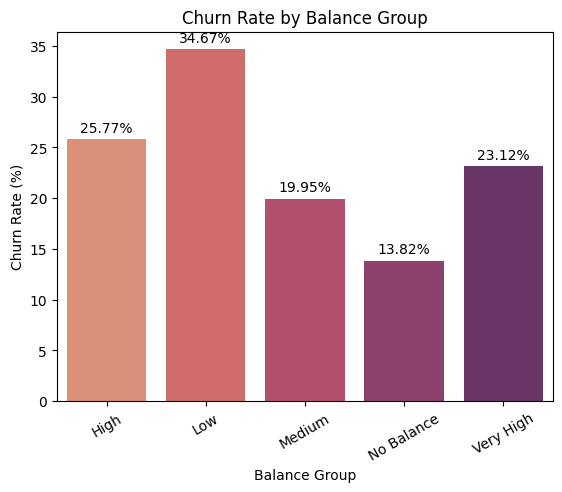

In [26]:
# churn by balance group
balance_churn = (
    df.groupby("BalanceGroup")["Exited"]
    .mean()
    .reset_index()
)

balance_churn["Exited"] *= 100

ax = sns.barplot(
    data=balance_churn,
    x="BalanceGroup",
    y="Exited",
    hue="BalanceGroup",
    palette="flare",
    legend=False
)

add_bar_labels(ax)

plt.title("Churn Rate by Balance Group")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

### Insight

Customers with low balances exhibit the highest churn rate (34.7%), while customers with no balance show the lowest churn rate (13.8%). Churn does not increase linearly with account balance, indicating that balance alone is not sufficient to explain customer behaviour. Additional factors such as customer engagement, product usage, and complaints likely interact with account balance to influence churn.